# 05 — Student Segmentation

This notebook trains and evaluates the student segmentation models using configuration values from `ml/config/config.json`.

The refactor removes notebook-level hardcoding for data paths, feature sources, K ranges, random seeds, model-save paths, segment label names, negative/reverse-scored variables, GMM settings, stability settings, CA pairs, satisfaction bins, and profiling display maps.

## Configuration-first design

Reusable settings are centralized under:

```text
ml/config/config.json -> segmentation
```

The notebook now keeps analysis logic in code and keeps change-prone constants in config. This reduces errors when the dataset version, K value, random seed, selected features, or final segment labels change.

In [1]:
from pathlib import Path
import sys
import json
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.ticker import FormatStrFormatter
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, normalized_mutual_info_score
import joblib

try:
    from kmodes.kmodes import KModes
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Missing dependency: kmodes. Install the ml project dependencies before running this notebook."
    ) from exc

try:
    import prince
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Missing dependency: prince. Install the ml project dependencies before running CA cells."
    ) from exc

# Make imports work from either project/ml or project/ml/notebook.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    src_dir = candidate / "src"
    config_file = candidate / "config" / "config.json"
    if src_dir.exists() and config_file.exists():
        ML_ROOT = candidate.resolve()
        if str(src_dir) not in sys.path:
            sys.path.insert(0, str(src_dir))
        break
else:
    raise FileNotFoundError("Could not find the ml project root containing config/config.json and src/.")

from blended_learning.config.settings import settings
from blended_learning.utils.io import resolve_path_from_settings, require_columns
from blended_learning.segmentation.preparation import prepare_kmodes_matrix as _prepare_kmodes_matrix, prepare_gmm_matrix
from blended_learning.segmentation.labeling import (
    add_segment_labels as _add_segment_labels,
    build_auto_cluster_name_map as _build_auto_cluster_name_map,
    pairwise_nmi,
    balance_cv,
    cluster_size_summary,
)

seg_cfg = settings.segmentation
RANDOM_STATE = seg_cfg["random_state"]

print(f"ML root: {ML_ROOT}")
print("Loaded segmentation config section from config/config.json")


ML root: /Users/ougi/Documents/Project/Blended-Learning/ml
Loaded segmentation config section from config/config.json


## 1. Load cleaned data and configured feature groups

In [2]:
io_cfg = seg_cfg["io"]
input_path = resolve_path_from_settings(settings, io_cfg["input_path_key"], from_path_dict=True)
df = pd.read_csv(input_path, **io_cfg.get("read_csv_options", {}))

feature_cfg = seg_cfg["feature_sources"]
cluster_vars = list(getattr(settings, feature_cfg["cluster_vars_key"]).keys())
multi_groups = dict(getattr(settings, feature_cfg["multi_groups_key"]))
pretty_label = dict(getattr(settings, feature_cfg["pretty_label_key"]))

require_columns(df, cluster_vars, "segmentation cluster variables")

print(f"Loaded data: {input_path}")
print(f"Shape: {df.shape}")
print(f"Number of clustering variables: {len(cluster_vars)}")
df.head(2)


Loaded data: /Users/ougi/Documents/Project/Blended-Learning/ml/data/processed/cleaned_data.csv
Shape: (592, 87)
Number of clustering variables: 33


,gender,age,is_itc_student,itc_campus,province,itc_student_id,education_level,department,faculty,academic_year,...,career_preparation,ideal_balance,prefer_more_blended,open_strengths,open_challenges_suggestions,survey_start,survey_end,response_time_minutes,student_id,flag_speeder
0,Male,36,True,ITC Phnom Penh (Main Campus),Phnom Penh,e20210528,Year5 - Final Year,GIC,NaN,2021–2022,...,2,"More Online than Face-to-Face (e.g., 40% In-pe...",No,NaN,NaN,2026-03-12 00:35:35.641,2026-03-12 00:37:43.468,2.130450,e20210528,True
1,Male,23,True,ITC Phnom Penh (Main Campus),Phnom Penh,e20210686,Year5 - Final Year,GIC,NaN,2025–2026,...,3,"More Online than Face-to-Face (e.g., 40% In-pe...",Neutral/Unsure,Nothing,Nothing,2026-03-17 18:53:40.435,2026-03-17 18:56:16.257,2.597033,e20210686,True


## 2. Shared helper functions

In [3]:
def prepare_kmodes_matrix(data: pd.DataFrame, columns: list[str]) -> tuple[pd.DataFrame, np.ndarray]:
    """Notebook wrapper around src segmentation preparation logic."""
    return _prepare_kmodes_matrix(data, columns, seg_cfg["kmodes"])


def build_auto_cluster_name_map(
    data: pd.DataFrame,
    label_col: str,
    columns: list[str],
    negative_vars: list[str] | None = None,
) -> tuple[dict[int, str], pd.Series, list[int]]:
    """Notebook wrapper around config-driven semantic cluster labeling."""
    return _build_auto_cluster_name_map(
        data=data,
        label_col=label_col,
        columns=columns,
        segment_label_config=seg_cfg["segment_labels"],
        negative_vars=negative_vars,
    )


def add_segment_labels(data: pd.DataFrame, labels: np.ndarray) -> tuple[pd.DataFrame, dict[int, str], pd.Series, list[int]]:
    return _add_segment_labels(
        data=data,
        labels=labels,
        columns=cluster_vars,
        segment_label_config=seg_cfg["segment_labels"],
    )


def print_cluster_summary(labels: np.ndarray, title: str) -> None:
    print(title)
    for cid in sorted(np.unique(labels)):
        n = int((labels == cid).sum())
        print(f"  Cluster {cid}: {n} students ({n / len(labels) * 100:.1f}%)")


def add_satisfaction_bin(data: pd.DataFrame) -> pd.DataFrame:
    sat_cfg = seg_cfg["satisfaction_bin"]
    data[sat_cfg["output_col"]] = pd.cut(
        data[sat_cfg["source_col"]],
        bins=sat_cfg["bins"],
        labels=sat_cfg["labels"],
        include_lowest=sat_cfg.get("include_lowest", True),
    )
    data[sat_cfg["output_col"]] = pd.Categorical(
        data[sat_cfg["output_col"]],
        categories=sat_cfg["categories"],
        ordered=True,
    )
    return data


def shorten(label: object, maxlen: int | None = None) -> str:
    maxlen = maxlen or seg_cfg["correspondence_analysis"]["short_label_maxlen"]
    text = str(label)
    return text if len(text) <= maxlen else text[:maxlen - 2] + ".."


## 3. K-Modes main segmentation model

In [4]:
X_km, X_km_fit = prepare_kmodes_matrix(df, cluster_vars)
display(X_km.head())

K-Modes input shape: (592, 33)
K-Modes total nulls: 0


,use_lecture_slides,use_video_lectures,use_quizzes,use_articles,use_forums,use_simulations,online_discussion_participation,peer_collaboration,comfort_asking_questions,sense_of_community,...,digital_literacy_improvement,tech_issues_freq,lms_usability,overall_satisfaction,benefit_flexibility,benefit_variety,benefit_recorded_access,benefit_self_study_time,benefit_life_balance,benefit_self_directed
0,1,2,3,4,5,1,3,2,4,3,...,1,2,3,4,4,3,5,2,1,2
1,3,3,3,4,4,4,3,4,3,4,...,4,3,3,4,3,4,4,4,1,4
2,4,4,4,3,4,4,4,4,3,3,...,5,3,4,4,4,3,4,4,3,5
3,5,5,3,3,3,3,3,3,3,3,...,4,4,4,3,3,3,4,4,4,4
4,3,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3


In [5]:
km_cfg = seg_cfg["kmodes"]
km_elbow_results = []

for k in km_cfg["elbow_k_values"]:
    costs = []
    for seed in range(km_cfg["elbow_n_runs"]):
        km = KModes(
            n_clusters=k,
            init=km_cfg["init_for_k1"] if k == 1 else km_cfg["init_default"],
            n_init=km_cfg["candidate_n_init"],
            random_state=seed,
            verbose=0,
        )
        km.fit_predict(X_km_fit)
        costs.append(km.cost_)
    km_elbow_results.append({"k": k, "best_cost": np.min(costs), "mean_cost": np.mean(costs), "sd_cost": np.std(costs)})

km_elbow_df = pd.DataFrame(km_elbow_results)
display(km_elbow_df.round(4))

,k,best_cost,mean_cost,sd_cost
0,1,10747.0,10747.0,0.0000
1,2,9171.0,9171.8,2.4000
2,3,8799.0,8851.1,27.2083
3,4,8490.0,8565.7,52.4482
4,5,8291.0,8361.4,43.5435
5,6,8148.0,8216.6,44.1774


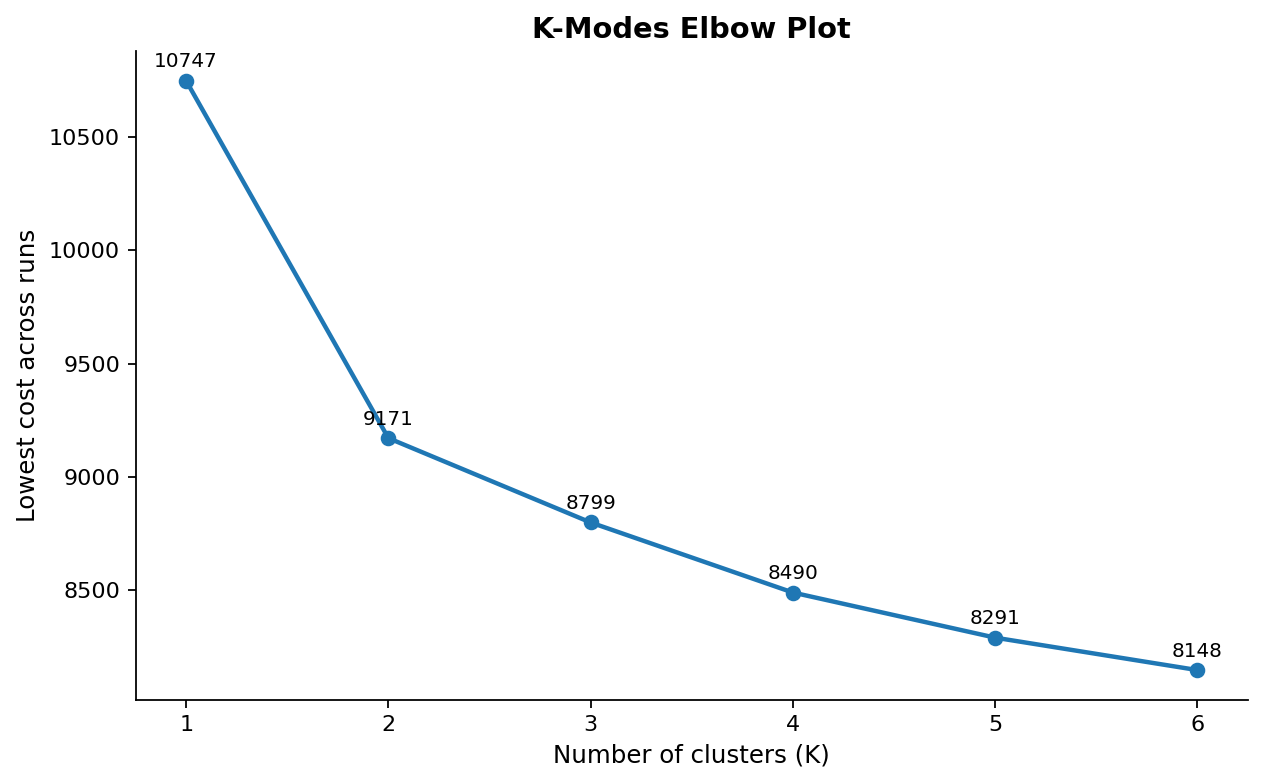

In [6]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=160)
ax.plot(km_elbow_df["k"], km_elbow_df["best_cost"], marker="o", linewidth=2)
ax.set_title("K-Modes Elbow Plot", fontsize=13, weight="bold")
ax.set_xlabel("Number of clusters (K)", fontsize=11)
ax.set_ylabel("Lowest cost across runs", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
for xi, yi in zip(km_elbow_df["k"], km_elbow_df["best_cost"]):
    ax.annotate(f"{yi:.0f}", (xi, yi), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
X_km_eval = X_km.apply(lambda col: pd.Categorical(col).codes)
km_diag_results = []

for k in km_cfg["diagnostic_k_values"]:
    labels_runs, costs, sils = [], [], []
    for seed in range(km_cfg["diagnostic_n_runs"]):
        km = KModes(n_clusters=k, init=km_cfg["init_default"], n_init=km_cfg["candidate_n_init"], random_state=seed, verbose=0)
        labels = km.fit_predict(X_km_fit)
        labels_runs.append(labels)
        costs.append(km.cost_)
        sils.append(silhouette_score(X_km_eval, labels, metric="hamming"))
    nmi_mean, nmi_std = pairwise_nmi(labels_runs)
    best_labels = labels_runs[int(np.argmin(costs))]
    counts = np.bincount(best_labels, minlength=k)
    km_diag_results.append({
        "k": k,
        "mean_silhouette": np.mean(sils),
        "sd_silhouette": np.std(sils),
        "mean_nmi": nmi_mean,
        "sd_nmi": nmi_std,
        "min_cluster_size": counts.min(),
        "max_cluster_size": counts.max(),
        "balance_ratio": counts.min() / counts.max(),
    })

km_diag_df = pd.DataFrame(km_diag_results)
display(km_diag_df.round(4))

,k,mean_silhouette,sd_silhouette,mean_nmi,sd_nmi,min_cluster_size,max_cluster_size,balance_ratio
0,2,0.1229,0.0004,0.9200,0.1044,233,359,0.6490
1,3,0.0800,0.0150,0.4162,0.0841,116,319,0.3636
2,4,0.0674,0.0182,0.4152,0.0835,69,274,0.2518
3,5,0.0559,0.0104,0.3764,0.0513,61,155,0.3935
4,6,0.0576,0.0059,0.3869,0.0413,44,171,0.2573


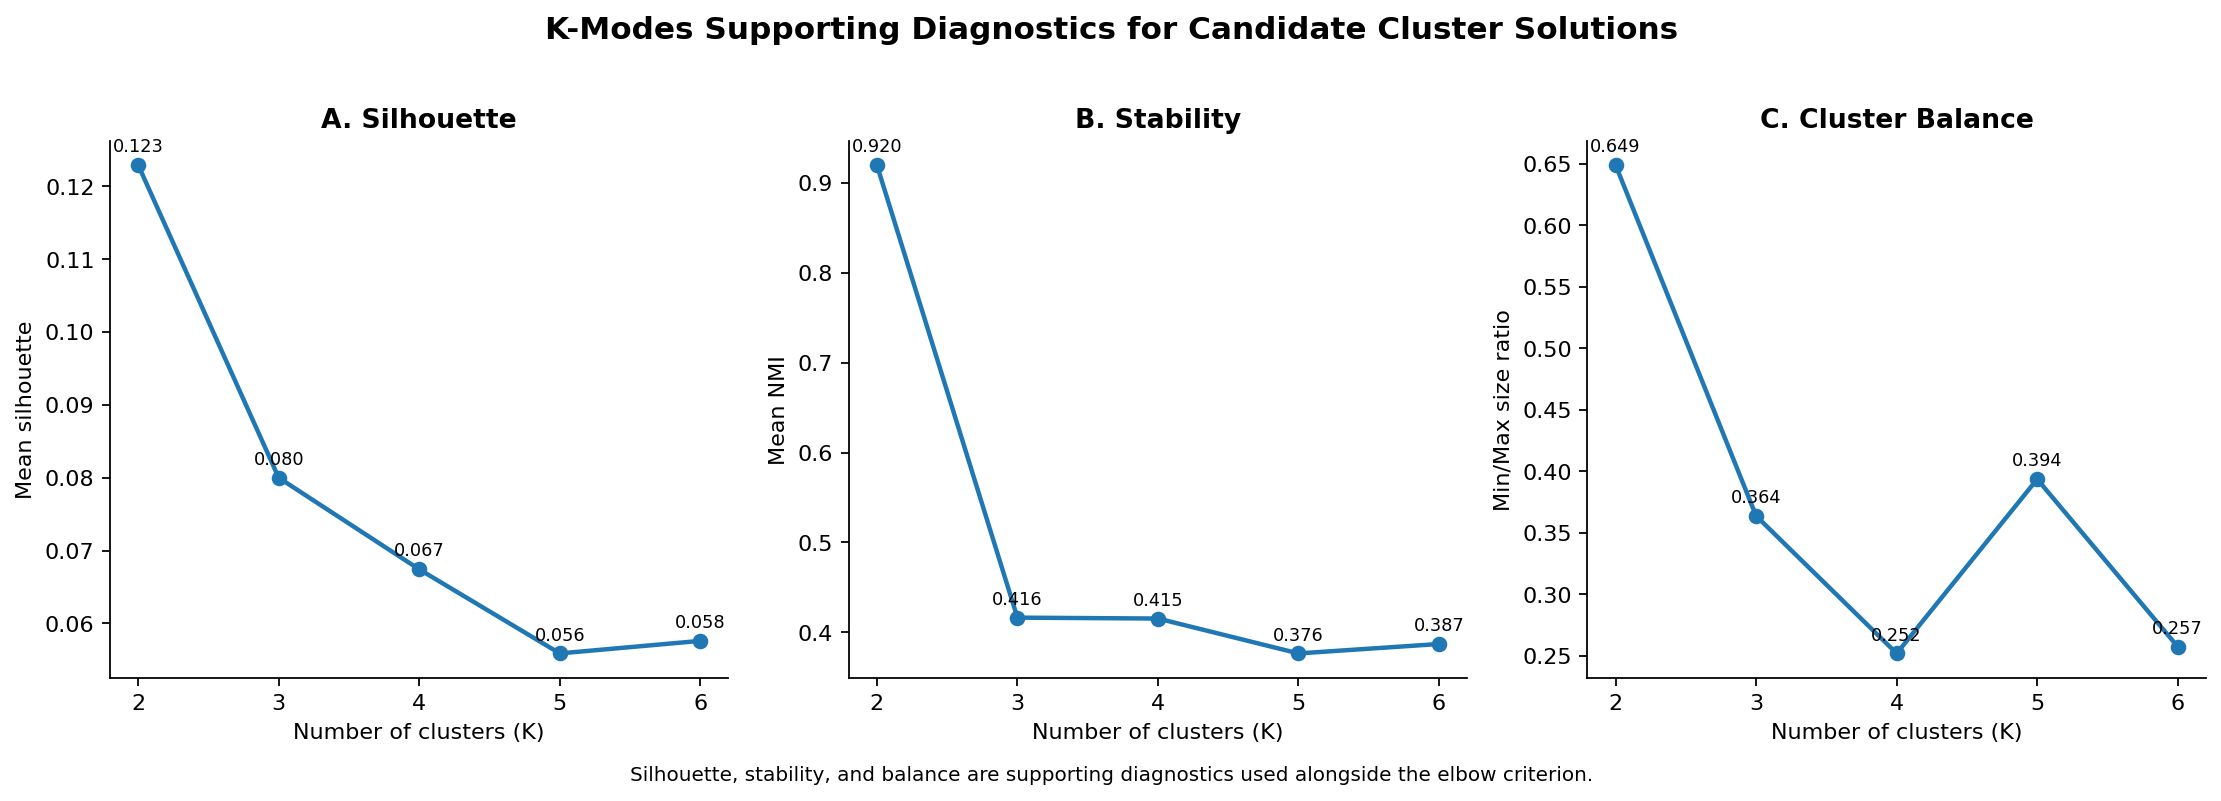

In [8]:
k_vals = km_diag_df["k"].tolist()
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), dpi=160)
fig.patch.set_facecolor("white")

def style_ax(ax):
    ax.set_xticks(k_vals)
    ax.xaxis.set_major_formatter(FormatStrFormatter("%d"))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=10)

def annotate_points(ax, x, y, fmt):
    for xi, yi in zip(x, y):
        ax.annotate(fmt.format(yi), (xi, yi), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8)

panels = [("mean_silhouette", "A. Silhouette", "Mean silhouette", "{:.3f}"), ("mean_nmi", "B. Stability", "Mean NMI", "{:.3f}"), ("balance_ratio", "C. Cluster Balance", "Min/Max size ratio", "{:.3f}")]
for ax, (col, title, ylabel, fmt) in zip(axes, panels):
    ax.plot(km_diag_df["k"], km_diag_df[col], marker="o", linewidth=2)
    style_ax(ax)
    annotate_points(ax, km_diag_df["k"], km_diag_df[col], fmt)
    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_xlabel("Number of clusters (K)", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
fig.suptitle("K-Modes Supporting Diagnostics for Candidate Cluster Solutions", fontsize=14, weight="bold", y=1.02)
fig.text(0.5, -0.02, "Silhouette, stability, and balance are supporting diagnostics used alongside the elbow criterion.", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

In [9]:
km_final = KModes(
    n_clusters=km_cfg["final_k"],
    init=km_cfg["final_init"],
    n_init=km_cfg["final_n_init"],
    random_state=km_cfg["final_random_state"],
    verbose=0,
)
idx = df.index
km_labels = km_final.fit_predict(X_km_fit) + km_cfg["label_offset"]
df, cluster_name_map, cluster_engagement_score, ranked_clusters = add_segment_labels(df, km_labels)

print_cluster_summary(km_labels, f"K-Modes final model K={km_cfg['final_k']}")
print("\nAuto cluster labels:")
for cluster_id, label in cluster_name_map.items():
    print(f"Cluster {cluster_id}: {label}")
print("\nCluster engagement scores:")
print(cluster_engagement_score.sort_values(ascending=False))

K-Modes final model K=2
  Cluster 1: 263 students (44.4%)
  Cluster 2: 329 students (55.6%)

Auto cluster labels:
Cluster 2: Highly Engaged (Active) Learners
Cluster 1: Moderately Engaged (Passive) Learners

Cluster engagement scores:
student_segment
2    3.878788
1    3.181818
dtype: float64


## 4. K-Modes profile and segment distribution

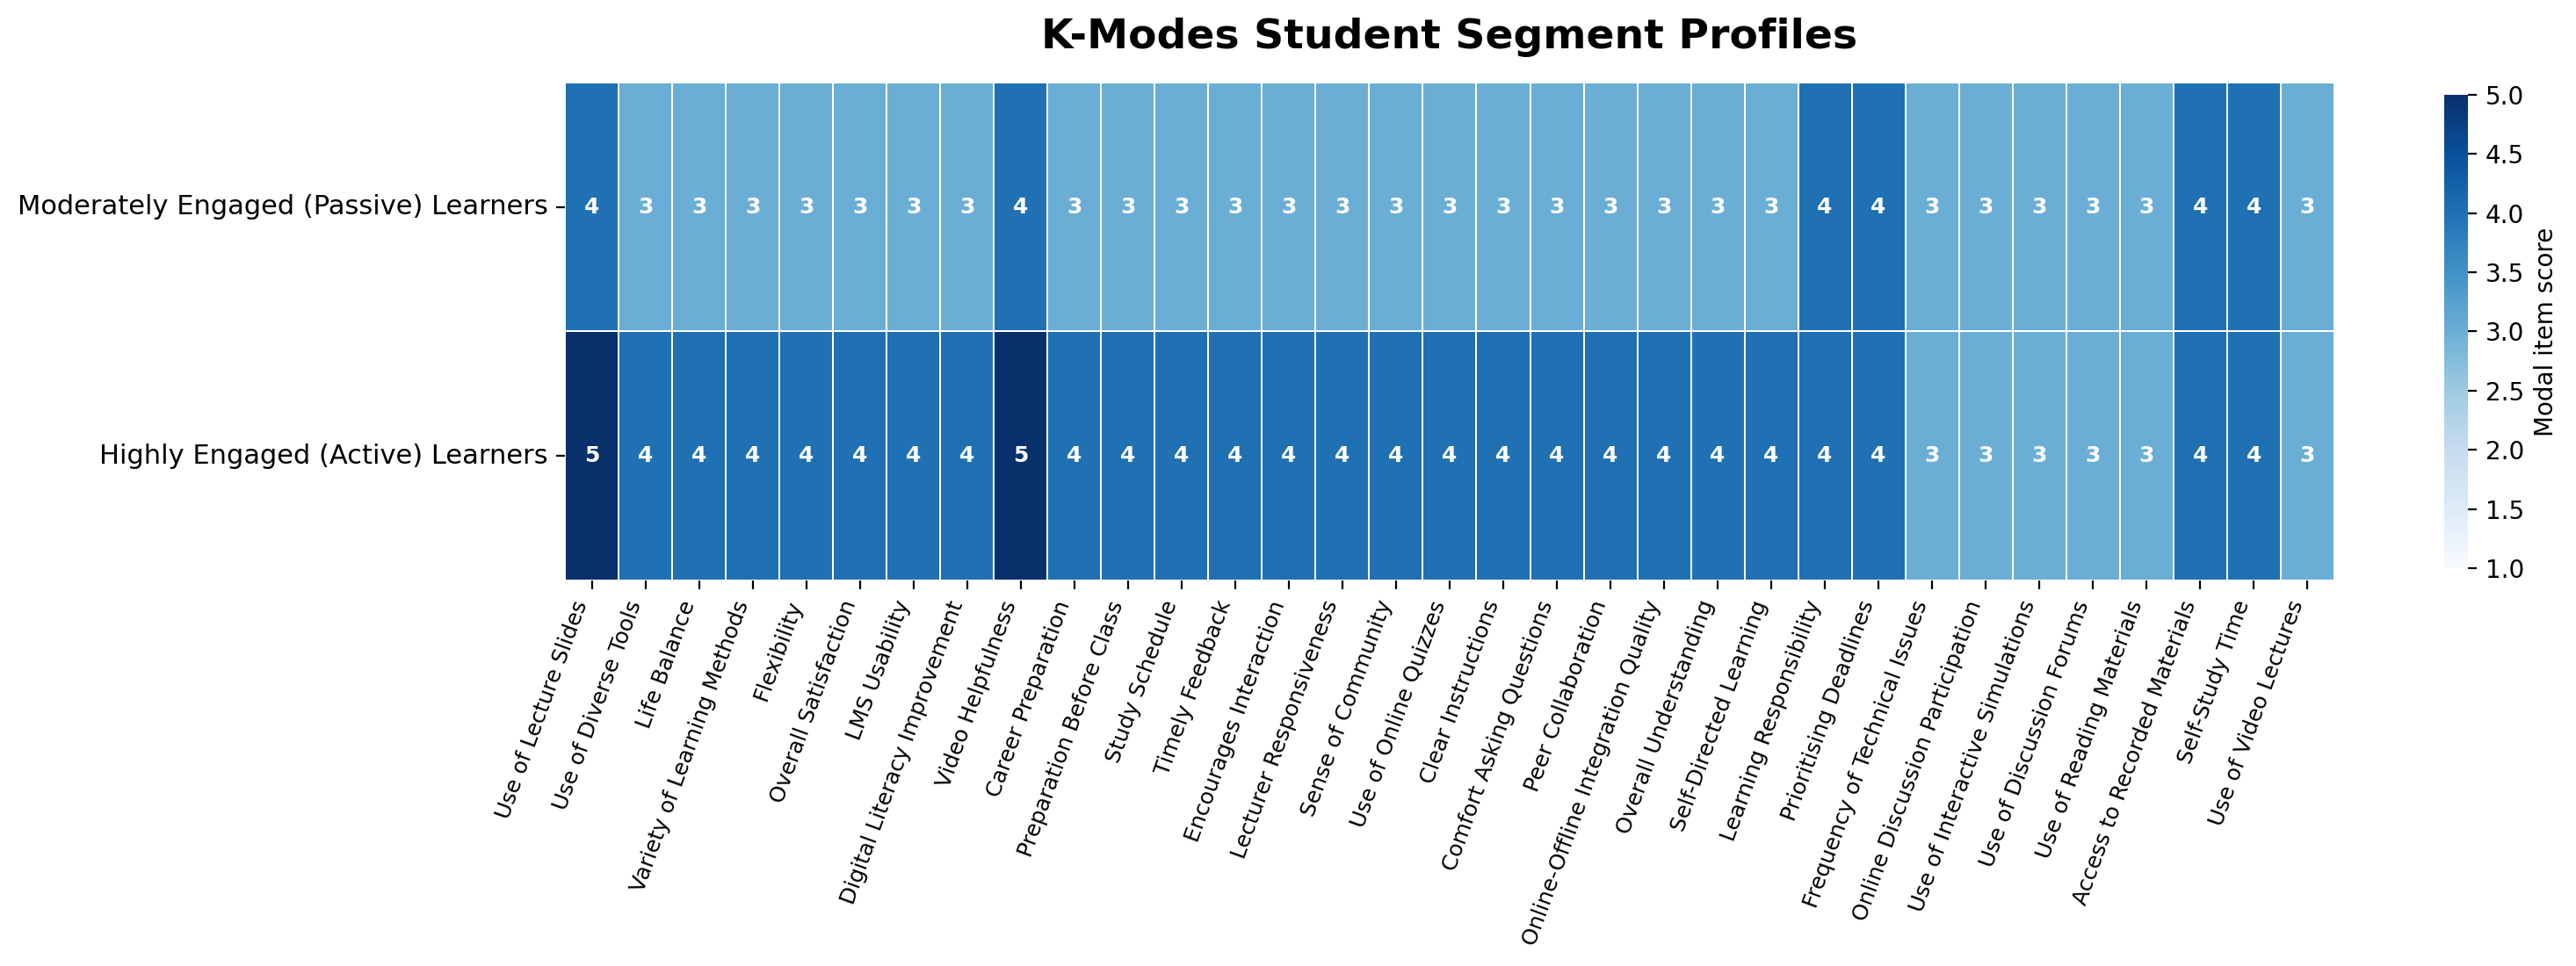

In [10]:
profile_cfg = seg_cfg["profiling"]["modal_profile_heatmap"]
km_profile = df.groupby(seg_cfg["segment_labels"]["id_column"])[cluster_vars].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
km_profile.index = [cluster_name_map.get(int(i), f"Cluster {i}") for i in km_profile.index]

if km_profile.shape[0] == 2:
    diff_order = (km_profile.iloc[0] - km_profile.iloc[1]).abs().sort_values(ascending=False).index
else:
    diff_order = km_profile.var(axis=0).sort_values(ascending=False).index

km_profile_plot = km_profile[diff_order].copy()
display_cols_ordered = [pretty_label.get(c, c.replace("_", " ").title()) for c in km_profile_plot.columns]

plt.figure(figsize=tuple(profile_cfg["figsize"]), dpi=profile_cfg["dpi"])
ax = sns.heatmap(
    km_profile_plot,
    cmap=profile_cfg["cmap"],
    vmin=profile_cfg["vmin"],
    vmax=profile_cfg["vmax"],
    annot=True,
    fmt=".0f",
    annot_kws={"size": 9, "weight": "bold"},
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"label": profile_cfg["cbar_label"], "shrink": 0.95},
)
ax.set_title("K-Modes Student Segment Profiles", fontsize=17, weight="bold", pad=14)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(display_cols_ordered, rotation=70, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

In [11]:
label_cfg = seg_cfg["segment_labels"]
cluster_order = ranked_clusters[::-1] if len(ranked_clusters) == 2 else ranked_clusters
cluster_counts = df[label_cfg["id_column"]].value_counts().reindex(cluster_order).fillna(0).astype(int)
cluster_perc = (cluster_counts / cluster_counts.sum() * 100).round(1)
segment_color_map = seg_cfg["bar_charts"]["segment_color_map"]
default_color = seg_cfg["bar_charts"]["default_color"]

x_labels = [label_cfg["axis_label_template"].format(cluster_id=k, segment_label=cluster_name_map[k]) for k in cluster_order]
colors = [segment_color_map.get(cluster_name_map[k], default_color) for k in cluster_order]

fig = make_subplots(rows=1, cols=2, specs=[[{"type": "xy"}, {"type": "domain"}]], column_widths=[0.64, 0.36], subplot_titles=("Cluster Sizes", "Cluster Proportions"), horizontal_spacing=0.08)
fig.add_trace(go.Bar(x=x_labels, y=cluster_counts.values, marker=dict(color=colors, line=dict(color="rgba(40,40,40,0.9)", width=1.2)), text=[f"{n}<br>{p}%" for n, p in zip(cluster_counts.values, cluster_perc.values)], textposition="outside", textfont=dict(size=13), customdata=cluster_perc.values, hovertemplate="<b>%{x}</b><br>Students: %{y}<br>Percentage: %{customdata:.1f}%<extra></extra>", showlegend=False), row=1, col=1)
fig.add_trace(go.Pie(labels=[f"Cluster {k}: {cluster_name_map[k]}" for k in cluster_order], values=cluster_counts.values, hole=0.60, marker=dict(colors=colors, line=dict(color="white", width=2)), textinfo="percent", textfont=dict(size=12), hovertemplate="<b>%{label}</b><br>Students: %{value}<br>Percentage: %{percent}<extra></extra>", showlegend=False, sort=False), row=1, col=2)
fig.update_yaxes(range=[0, cluster_counts.max() * 1.20], title_text="Number of students", showgrid=True, gridcolor="rgba(0,0,0,0.08)", zeroline=False, row=1, col=1)
fig.update_xaxes(title_text="Cluster ID and profile", row=1, col=1)
fig.update_layout(title=dict(text="K-Modes Student Segment Distribution", x=0.5, xanchor="center", font=dict(size=22)), template="plotly_white", width=1250, height=700, margin=dict(t=120, l=60, r=40, b=90), showlegend=False)
fig.update_traces(width=0.6, selector=dict(type="bar"))
fig.show()

## 5. Save K-Modes model and metadata

In [12]:
model_cfg = seg_cfg["model_output"]
model_dir = resolve_path_from_settings(settings, model_cfg["model_dir"])
model_dir.mkdir(parents=True, exist_ok=True)

cluster_label_map_for_app = {
    int(cluster_id): label_cfg["saved_label_template"].format(cluster_id=int(cluster_id), segment_label=segment_label)
    for cluster_id, segment_label in sorted(cluster_name_map.items())
}

joblib.dump(km_final, model_dir / model_cfg["kmodes_model_filename"])
(model_dir / model_cfg["feature_columns_filename"]).write_text(json.dumps(cluster_vars, indent=2, ensure_ascii=False), encoding="utf-8")
(model_dir / model_cfg["cluster_label_map_filename"]).write_text(json.dumps(cluster_label_map_for_app, indent=2, ensure_ascii=False), encoding="utf-8")

preprocessing_info = {
    "description": model_cfg["preprocessing_description"],
    "steps": model_cfg["preprocessing_steps"],
    "n_features": len(cluster_vars),
    "model_input_type": km_cfg["model_input_type"],
    "k": km_cfg["final_k"],
    "random_state": km_cfg["final_random_state"],
    "label_offset": km_cfg["label_offset"],
    "segment_label_strategy": "auto-labeled from modal profile engagement score",
    "negative_vars": label_cfg["negative_vars"],
}
(model_dir / model_cfg["preprocessing_info_filename"]).write_text(json.dumps(preprocessing_info, indent=2, ensure_ascii=False), encoding="utf-8")

print("Saved K-Modes model and metadata.")
print(f"Model directory: {model_dir}")
print(f"Number of clustering features: {len(cluster_vars)}")
print("Saved cluster label map:")
print(json.dumps(cluster_label_map_for_app, indent=2, ensure_ascii=False))

Saved K-Modes model and metadata.
Model directory: /Users/ougi/Documents/Project/Blended-Learning/ml/models
Number of clustering features: 33
Saved cluster label map:
{
  "1": "Moderately Engaged (Passive) Learners",
  "2": "Highly Engaged (Active) Learners"
}


## 6. GMM comparison model

In [13]:
X_gmm, X_gmm_fit, gmm_scaler = prepare_gmm_matrix(df, cluster_vars)
display(X_gmm.head())
print("Scaled matrix shape:", X_gmm_fit.shape)
print("Scaled means (first 5):", np.round(X_gmm_fit.mean(axis=0)[:5], 3))
print("Scaled stds  (first 5):", np.round(X_gmm_fit.std(axis=0)[:5], 3))

GMM input shape: (592, 33)
GMM total nulls: 0


,use_lecture_slides,use_video_lectures,use_quizzes,use_articles,use_forums,use_simulations,online_discussion_participation,peer_collaboration,comfort_asking_questions,sense_of_community,...,digital_literacy_improvement,tech_issues_freq,lms_usability,overall_satisfaction,benefit_flexibility,benefit_variety,benefit_recorded_access,benefit_self_study_time,benefit_life_balance,benefit_self_directed
0,1.0,2.0,3.0,4.0,5.0,1.0,3.0,2.0,4.0,3.0,...,1.0,2.0,3.0,4.0,4.0,3.0,5.0,2.0,1.0,2.0
1,3.0,3.0,3.0,4.0,4.0,4.0,3.0,4.0,3.0,4.0,...,4.0,3.0,3.0,4.0,3.0,4.0,4.0,4.0,1.0,4.0
2,4.0,4.0,4.0,3.0,4.0,4.0,4.0,4.0,3.0,3.0,...,5.0,3.0,4.0,4.0,4.0,3.0,4.0,4.0,3.0,5.0
3,5.0,5.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,4.0,4.0,4.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0
4,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0


Scaled matrix shape: (592, 33)
Scaled means (first 5): [-0. -0. -0.  0. -0.]
Scaled stds  (first 5): [1. 1. 1. 1. 1.]


In [14]:
gmm_cfg = seg_cfg["gmm"]
gmm_results = []
for k in gmm_cfg["k_values"]:
    gmm = GaussianMixture(n_components=k, covariance_type=gmm_cfg["covariance_type"], n_init=gmm_cfg["n_init"], max_iter=gmm_cfg["max_iter"], random_state=RANDOM_STATE)
    gmm.fit(X_gmm_fit)
    gmm_results.append({"k": k, "bic": gmm.bic(X_gmm_fit), "aic": gmm.aic(X_gmm_fit), "log_likelihood": gmm.lower_bound_ * X_gmm_fit.shape[0]})

gmm_results_df = pd.DataFrame(gmm_results)
display(gmm_results_df.round(4))

,k,bic,aic,log_likelihood
0,1,53554.5626,50950.7596,-24881.3798
1,2,55402.0392,50190.0498,-23906.5738
2,3,58174.8080,50354.6321,-23393.8283
3,4,57988.5541,47560.1918,-21404.2452
4,5,61069.9822,48033.4335,-21043.9327
5,6,63719.5222,48074.7871,-20468.9574


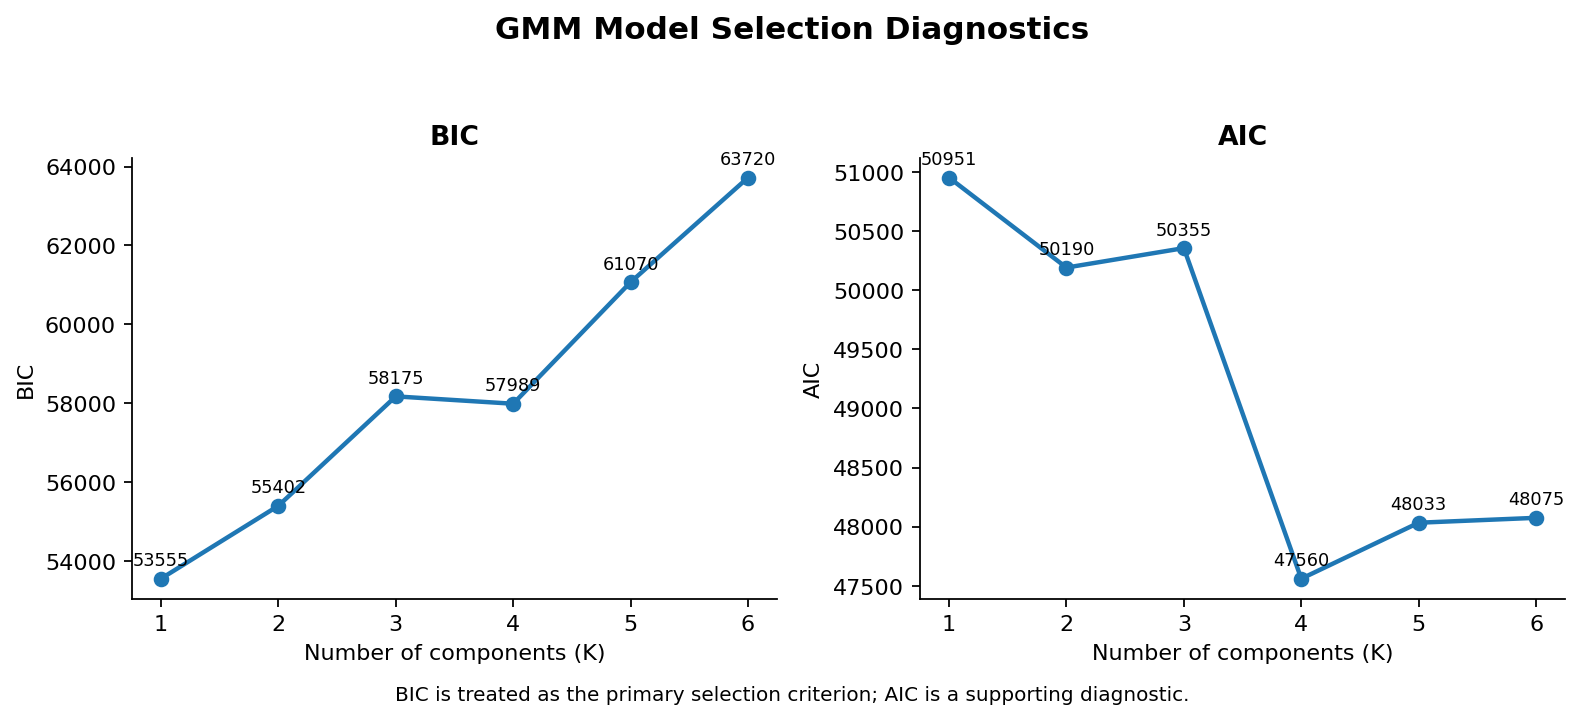

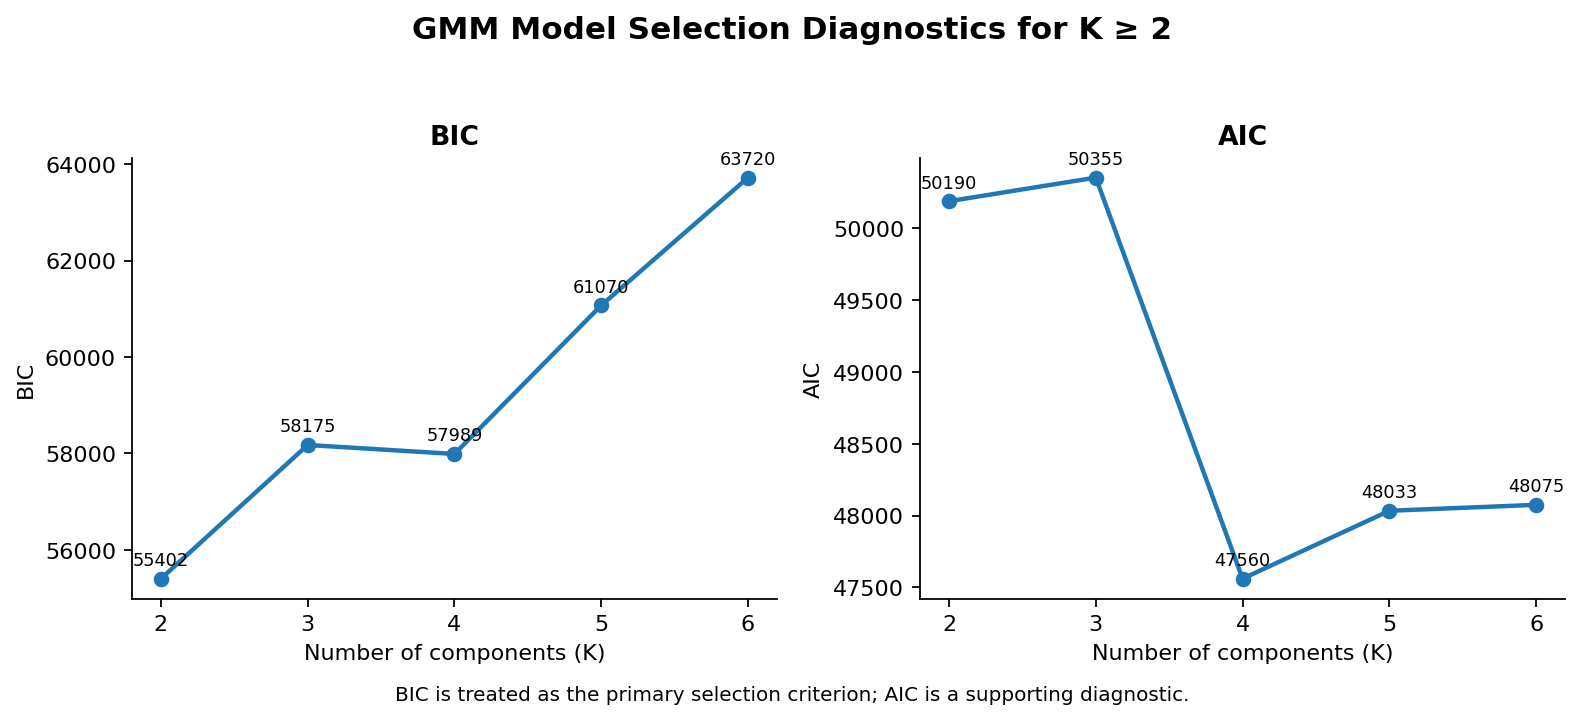

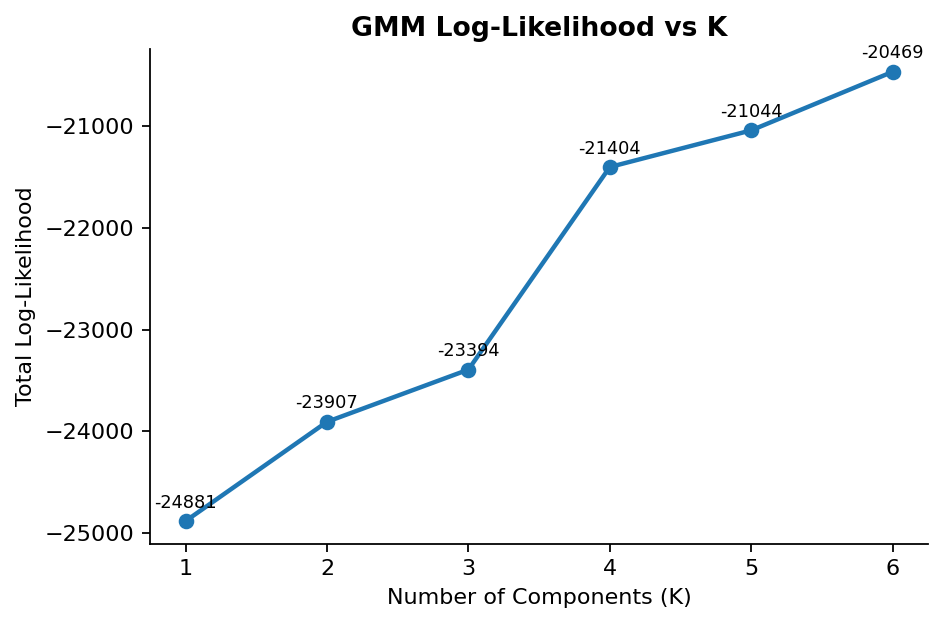

In [15]:
for plot_min, title in [(min(gmm_cfg["k_values"]), "GMM Model Selection Diagnostics"), (gmm_cfg["plot_min_k"], "GMM Model Selection Diagnostics for K ≥ 2")]:
    plot_df = gmm_results_df[gmm_results_df["k"] >= plot_min].copy()
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=160)
    fig.patch.set_facecolor("white")
    for ax, metric in zip(axes, ["bic", "aic"]):
        ax.plot(plot_df["k"], plot_df[metric], marker="o", linewidth=2)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(False)
        ax.tick_params(axis="both", labelsize=10)
        ax.xaxis.set_major_formatter(FormatStrFormatter("%d"))
        ax.set_xticks(plot_df["k"])
        for xi, yi in zip(plot_df["k"], plot_df[metric]):
            ax.annotate(f"{yi:.0f}", (xi, yi), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8)
        ax.set_title(metric.upper(), fontsize=12, weight="bold")
        ax.set_xlabel("Number of components (K)", fontsize=10)
        ax.set_ylabel(metric.upper(), fontsize=10)
    fig.suptitle(title, fontsize=14, weight="bold", y=1.05)
    fig.text(0.5, -0.02, "BIC is treated as the primary selection criterion; AIC is a supporting diagnostic.", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()

fig, ax = plt.subplots(figsize=(6, 4), dpi=160)
ax.plot(gmm_results_df["k"], gmm_results_df["log_likelihood"], marker="o", linewidth=2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.xaxis.set_major_formatter(FormatStrFormatter("%d"))
ax.set_xticks(gmm_results_df["k"])
for x, y in zip(gmm_results_df["k"], gmm_results_df["log_likelihood"]):
    ax.annotate(f"{y:.0f}", (x, y), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8)
ax.set_title("GMM Log-Likelihood vs K", fontsize=12, weight="bold")
ax.set_xlabel("Number of Components (K)", fontsize=10)
ax.set_ylabel("Total Log-Likelihood", fontsize=10)
plt.tight_layout()
plt.show()

In [16]:
gmm_final = GaussianMixture(n_components=gmm_cfg["final_k"], covariance_type=gmm_cfg["covariance_type"], n_init=gmm_cfg["n_init"], max_iter=gmm_cfg["max_iter"], random_state=RANDOM_STATE)
gmm_final.fit(X_gmm_fit)
gmm_proba = gmm_final.predict_proba(X_gmm_fit)
gmm_labels = gmm_final.predict(X_gmm_fit) + km_cfg["label_offset"]
gmm_entropy = -np.sum(gmm_proba * np.log(gmm_proba + 1e-12), axis=1)
max_prob = gmm_proba.max(axis=1)
high_threshold = gmm_cfg["confidence_thresholds"]["high"]
ambiguous_threshold = gmm_cfg["confidence_thresholds"]["ambiguous"]

df.loc[idx, "gmm_cluster_id"] = gmm_labels
df.loc[idx, "gmm_entropy"] = gmm_entropy
for k in range(gmm_cfg["final_k"]):
    df.loc[idx, f"gmm_prob_c{k + 1}"] = gmm_proba[:, k]

print(f"GMM comparison model K={gmm_cfg['final_k']} cov={gmm_cfg['covariance_type']} converged={gmm_final.converged_}")
print(f"  BIC              : {gmm_final.bic(X_gmm_fit):.2f}")
print(f"  AIC              : {gmm_final.aic(X_gmm_fit):.2f}")
print(f"  Log-likelihood   : {gmm_final.lower_bound_:.4f}")
print(f"  Mean entropy     : {gmm_entropy.mean():.4f}  (lower = more confident)")
print(f"  p >= {high_threshold:.2f}       : {(max_prob >= high_threshold).sum()} ({(max_prob >= high_threshold).mean()*100:.1f}%)")
print(f"  p < {ambiguous_threshold:.2f}        : {(max_prob < ambiguous_threshold).sum()} ({(max_prob < ambiguous_threshold).mean()*100:.1f}%)")
print_cluster_summary(gmm_labels, "\nGMM cluster distribution:")

GMM comparison model K=2 cov=full converged=True
  BIC              : 55402.04
  AIC              : 50190.05
  Log-likelihood   : -40.3827
  Mean entropy     : 0.0279  (lower = more confident)
  p >= 0.90       : 584 (98.6%)
  p < 0.60        : 2 (0.3%)

GMM cluster distribution:
  Cluster 1: 439 students (74.2%)
  Cluster 2: 153 students (25.8%)


In [17]:
gmm_profile = df.groupby("gmm_cluster_id")[cluster_vars].mean().round(2)
display(gmm_profile)

extra_k = gmm_cfg["extra_component_check_k"]
gmm_extra = GaussianMixture(n_components=extra_k, covariance_type=gmm_cfg["covariance_type"], n_init=gmm_cfg["n_init"], max_iter=gmm_cfg["max_iter"], random_state=RANDOM_STATE)
gmm_extra.fit(X_gmm_fit)
gmm_labels_extra = gmm_extra.predict(X_gmm_fit) + km_cfg["label_offset"]
print(f"Extra GMM K={extra_k} component-size check:")
print(Counter(gmm_labels_extra))

,use_lecture_slides,use_video_lectures,use_quizzes,use_articles,use_forums,use_simulations,online_discussion_participation,peer_collaboration,comfort_asking_questions,sense_of_community,...,digital_literacy_improvement,tech_issues_freq,lms_usability,overall_satisfaction,benefit_flexibility,benefit_variety,benefit_recorded_access,benefit_self_study_time,benefit_life_balance,benefit_self_directed
gmm_cluster_id,,,,,,,,,,,,,,,,,,,,,
1.0,4.10,3.40,3.67,3.06,3.08,2.92,3.01,3.40,3.48,3.31,...,3.53,3.28,3.54,3.60,3.75,3.69,3.94,3.99,3.73,3.85
2.0,4.08,3.05,3.55,3.10,2.76,2.52,2.54,3.17,3.15,2.95,...,3.01,3.44,3.09,3.14,3.51,3.40,3.88,3.81,3.51,3.67


Extra GMM K=4 component-size check:
Counter({3: 371, 2: 129, 1: 77, 4: 15})


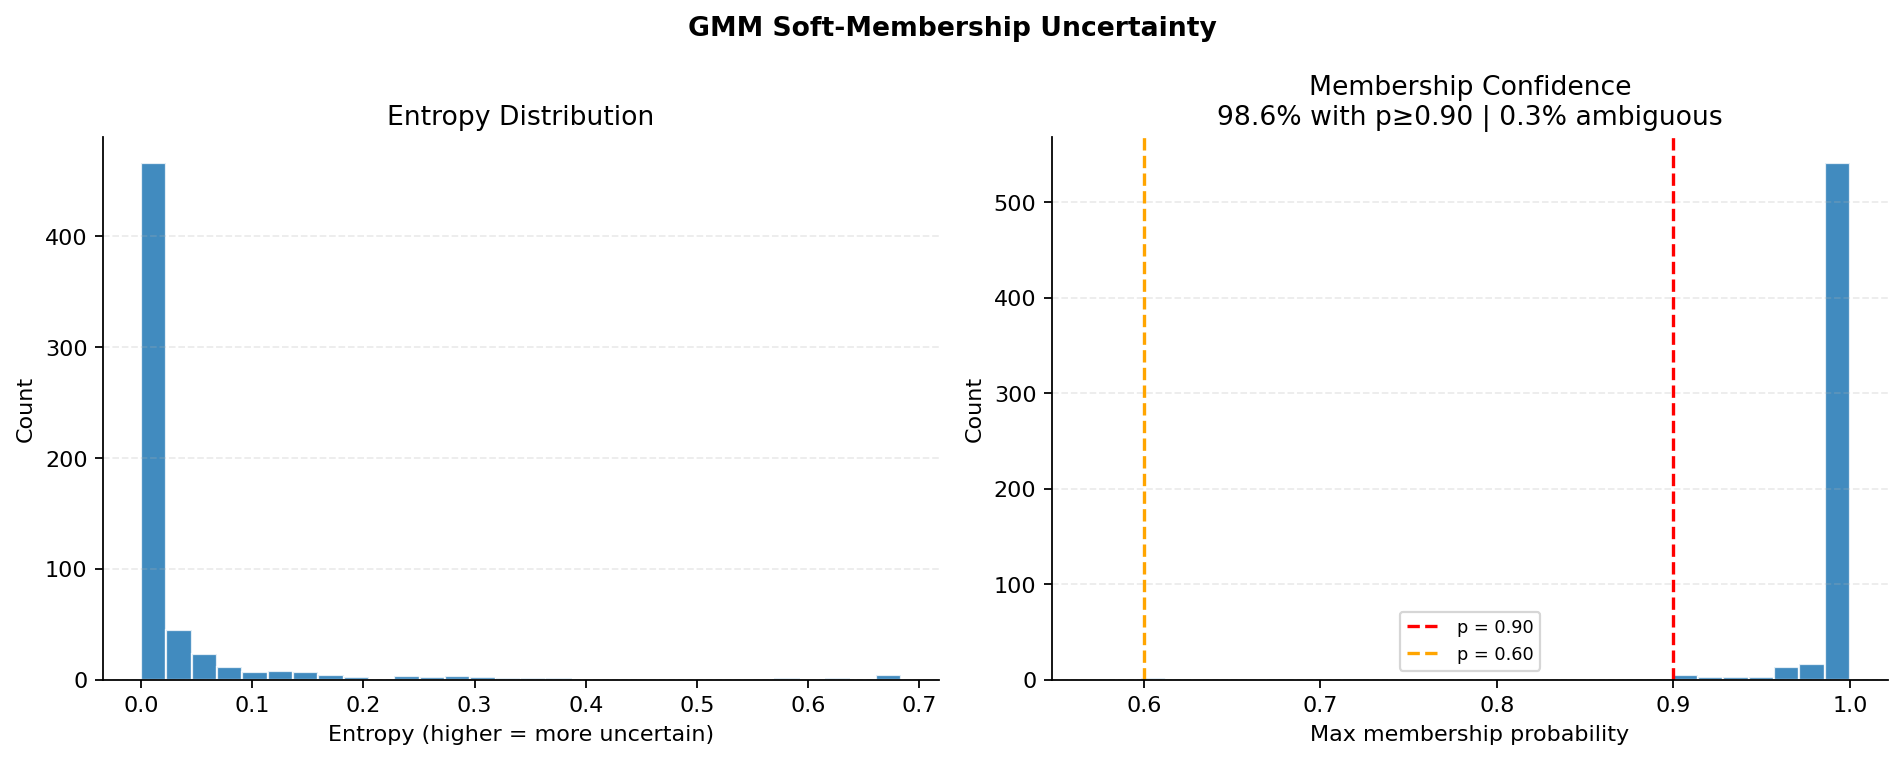

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8), dpi=160)
fig.suptitle("GMM Soft-Membership Uncertainty", fontsize=12, fontweight="bold")
ax1.hist(gmm_entropy, bins=30, edgecolor="white", alpha=0.85)
ax1.set_title("Entropy Distribution")
ax1.set_xlabel("Entropy (higher = more uncertain)")
ax1.set_ylabel("Count")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(True, axis="y", alpha=0.25, linestyle="--")
ax2.hist(max_prob, bins=30, edgecolor="white", alpha=0.85)
ax2.axvline(high_threshold, color="red", linestyle="--", linewidth=1.5, label=f"p = {high_threshold:.2f}")
ax2.axvline(ambiguous_threshold, color="orange", linestyle="--", linewidth=1.5, label=f"p = {ambiguous_threshold:.2f}")
ax2.set_title(f"Membership Confidence\n{(max_prob >= high_threshold).mean()*100:.1f}% with p≥{high_threshold:.2f} | {(max_prob < ambiguous_threshold).mean()*100:.1f}% ambiguous")
ax2.set_xlabel("Max membership probability")
ax2.set_ylabel("Count")
ax2.legend(fontsize=8)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(True, axis="y", alpha=0.25, linestyle="--")
plt.tight_layout()
plt.show()

## 7. Stability and shared model comparison

In [19]:
stab_cfg = seg_cfg["stability"]
K_BEST = km_cfg["final_k"]
SEEDS = [RANDOM_STATE + i * stab_cfg["seed_step"] for i in range(stab_cfg["n_runs"])]

gmm_lbl_list, km_lbl_list = [], []
print(f"Running {stab_cfg['n_runs']} seed runs at K={K_BEST} ...")
t0 = time.time()
for seed in SEEDS:
    gmm = GaussianMixture(n_components=K_BEST, covariance_type=gmm_cfg["covariance_type"], n_init=gmm_cfg["stability_n_init"], max_iter=gmm_cfg["max_iter"], random_state=seed)
    gmm.fit(X_gmm_fit)
    gmm_lbl_list.append(gmm.predict(X_gmm_fit))
    km = KModes(n_clusters=K_BEST, init=km_cfg["init_default"], n_init=km_cfg["candidate_n_init"], random_state=seed, verbose=0)
    km_lbl_list.append(km.fit_predict(X_km_fit))

GMM_NMI, gmm_nmi_std = pairwise_nmi(gmm_lbl_list)
KM_NMI, km_nmi_std = pairwise_nmi(km_lbl_list)

print(f"Done in {time.time() - t0:.1f}s\n")
print("=" * 56)
print(f"  STABILITY — PAIRWISE NMI (K={K_BEST}, {stab_cfg['n_runs']} seeds)")
print("=" * 56)
print(f"  K-Modes (main)      : {KM_NMI:.4f} ± {km_nmi_std:.4f}")
print(f"  GMM (comparison)    : {GMM_NMI:.4f} ± {gmm_nmi_std:.4f}")
print(f"\n  NMI >= {stab_cfg['nmi_threshold']:.2f} = stable | NMI < {stab_cfg['nmi_threshold']:.2f} = sensitive to initialization")

Running 30 seed runs at K=2 ...
Done in 652.3s

  STABILITY — PAIRWISE NMI (K=2, 30 seeds)
  K-Modes (main)      : 0.8659 ± 0.0931
  GMM (comparison)    : 0.7697 ± 0.1419

  NMI >= 0.80 = stable | NMI < 0.80 = sensitive to initialization


In [20]:
km_min, km_max = cluster_size_summary(km_labels)
gmm_min, gmm_max = cluster_size_summary(gmm_labels)
shared_df = pd.DataFrame([
    {"Model": "K-Modes (main)", "Stability NMI": round(KM_NMI, 4), "Balance CV": round(balance_cv(km_labels), 4), "Min cluster size": km_min, "Max cluster size": km_max},
    {"Model": "GMM (comparison)", "Stability NMI": round(GMM_NMI, 4), "Balance CV": round(balance_cv(gmm_labels), 4), "Min cluster size": gmm_min, "Max cluster size": gmm_max},
]).set_index("Model")
print(shared_df.to_string())
display(shared_df)

                  Stability NMI  Balance CV  Min cluster size  Max cluster size
Model                                                                          
K-Modes (main)           0.8659      0.1115               263               329
GMM (comparison)         0.7697      0.4831               153               439


,Stability NMI,Balance CV,Min cluster size,Max cluster size
Model,,,,
K-Modes (main),0.8659,0.1115,263,329
GMM (comparison),0.7697,0.4831,153,439


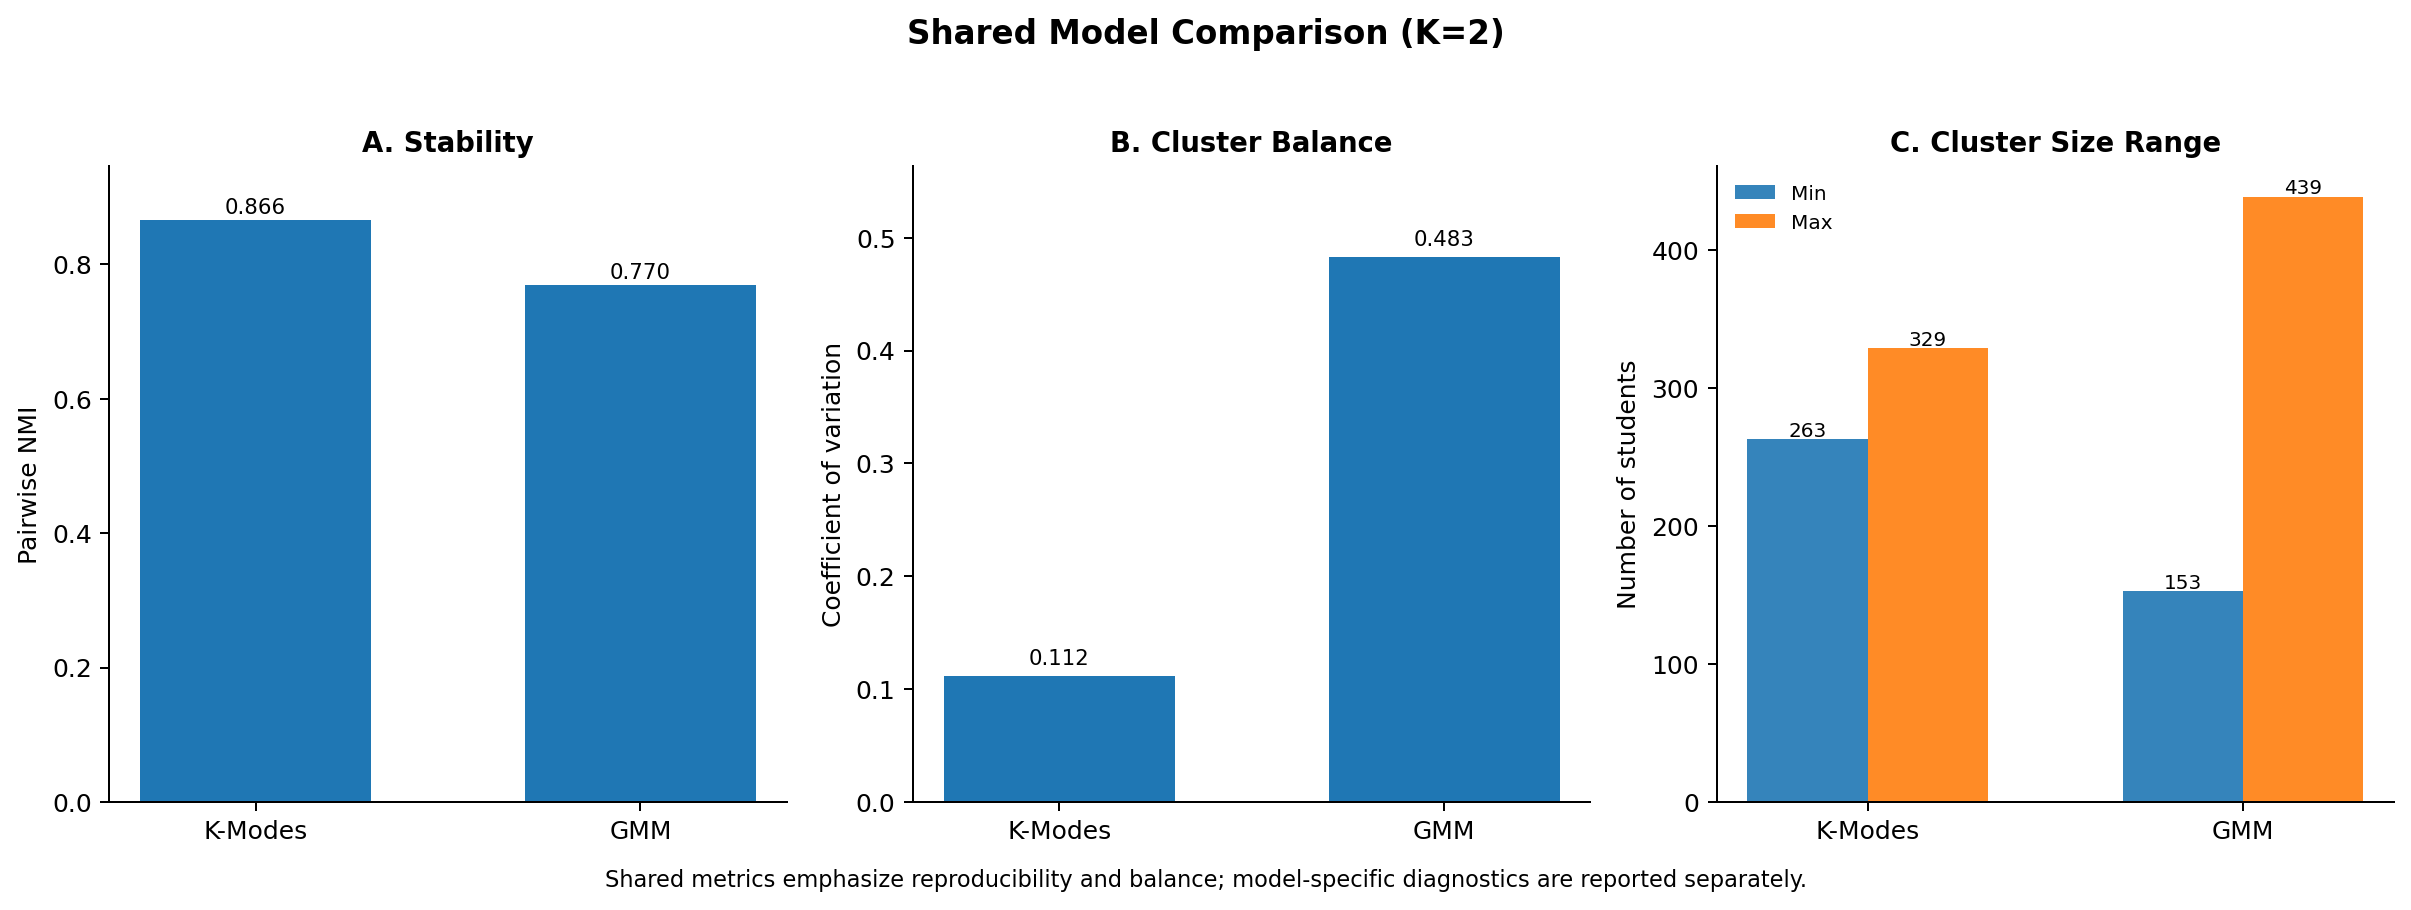

In [21]:
plot_df = shared_df.copy()
plot_df.index = ["K-Modes", "GMM"]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), dpi=180)
fig.suptitle(f"Shared Model Comparison (K={K_BEST})", fontsize=13, fontweight="bold", y=1.03)
for ax, metric, title, ylabel in [(axes[0], "Stability NMI", "A. Stability", "Pairwise NMI"), (axes[1], "Balance CV", "B. Cluster Balance", "Coefficient of variation")]:
    bars = ax.bar(plot_df.index, plot_df[metric], width=0.6)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_ylim(0, max(plot_df[metric]) + 0.08)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    for bar, v in zip(bars, plot_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=8.5)
ax = axes[2]
x = np.arange(len(plot_df.index))
mins = plot_df["Min cluster size"].values
maxs = plot_df["Max cluster size"].values
bars1 = ax.bar(x - 0.16, mins, width=0.32, label="Min", alpha=0.9)
bars2 = ax.bar(x + 0.16, maxs, width=0.32, label="Max", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index)
ax.set_title("C. Cluster Size Range", fontsize=11, fontweight="bold")
ax.set_ylabel("Number of students", fontsize=10)
ax.legend(frameon=False, fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
for bar, v in zip(bars1, mins):
    ax.text(bar.get_x() + bar.get_width()/2, v + 2, f"{v}", ha="center", fontsize=8)
for bar, v in zip(bars2, maxs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 2, f"{v}", ha="center", fontsize=8)
fig.text(0.5, -0.02, "Shared metrics emphasize reproducibility and balance; model-specific diagnostics are reported separately.", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 8. PCA visual comparison

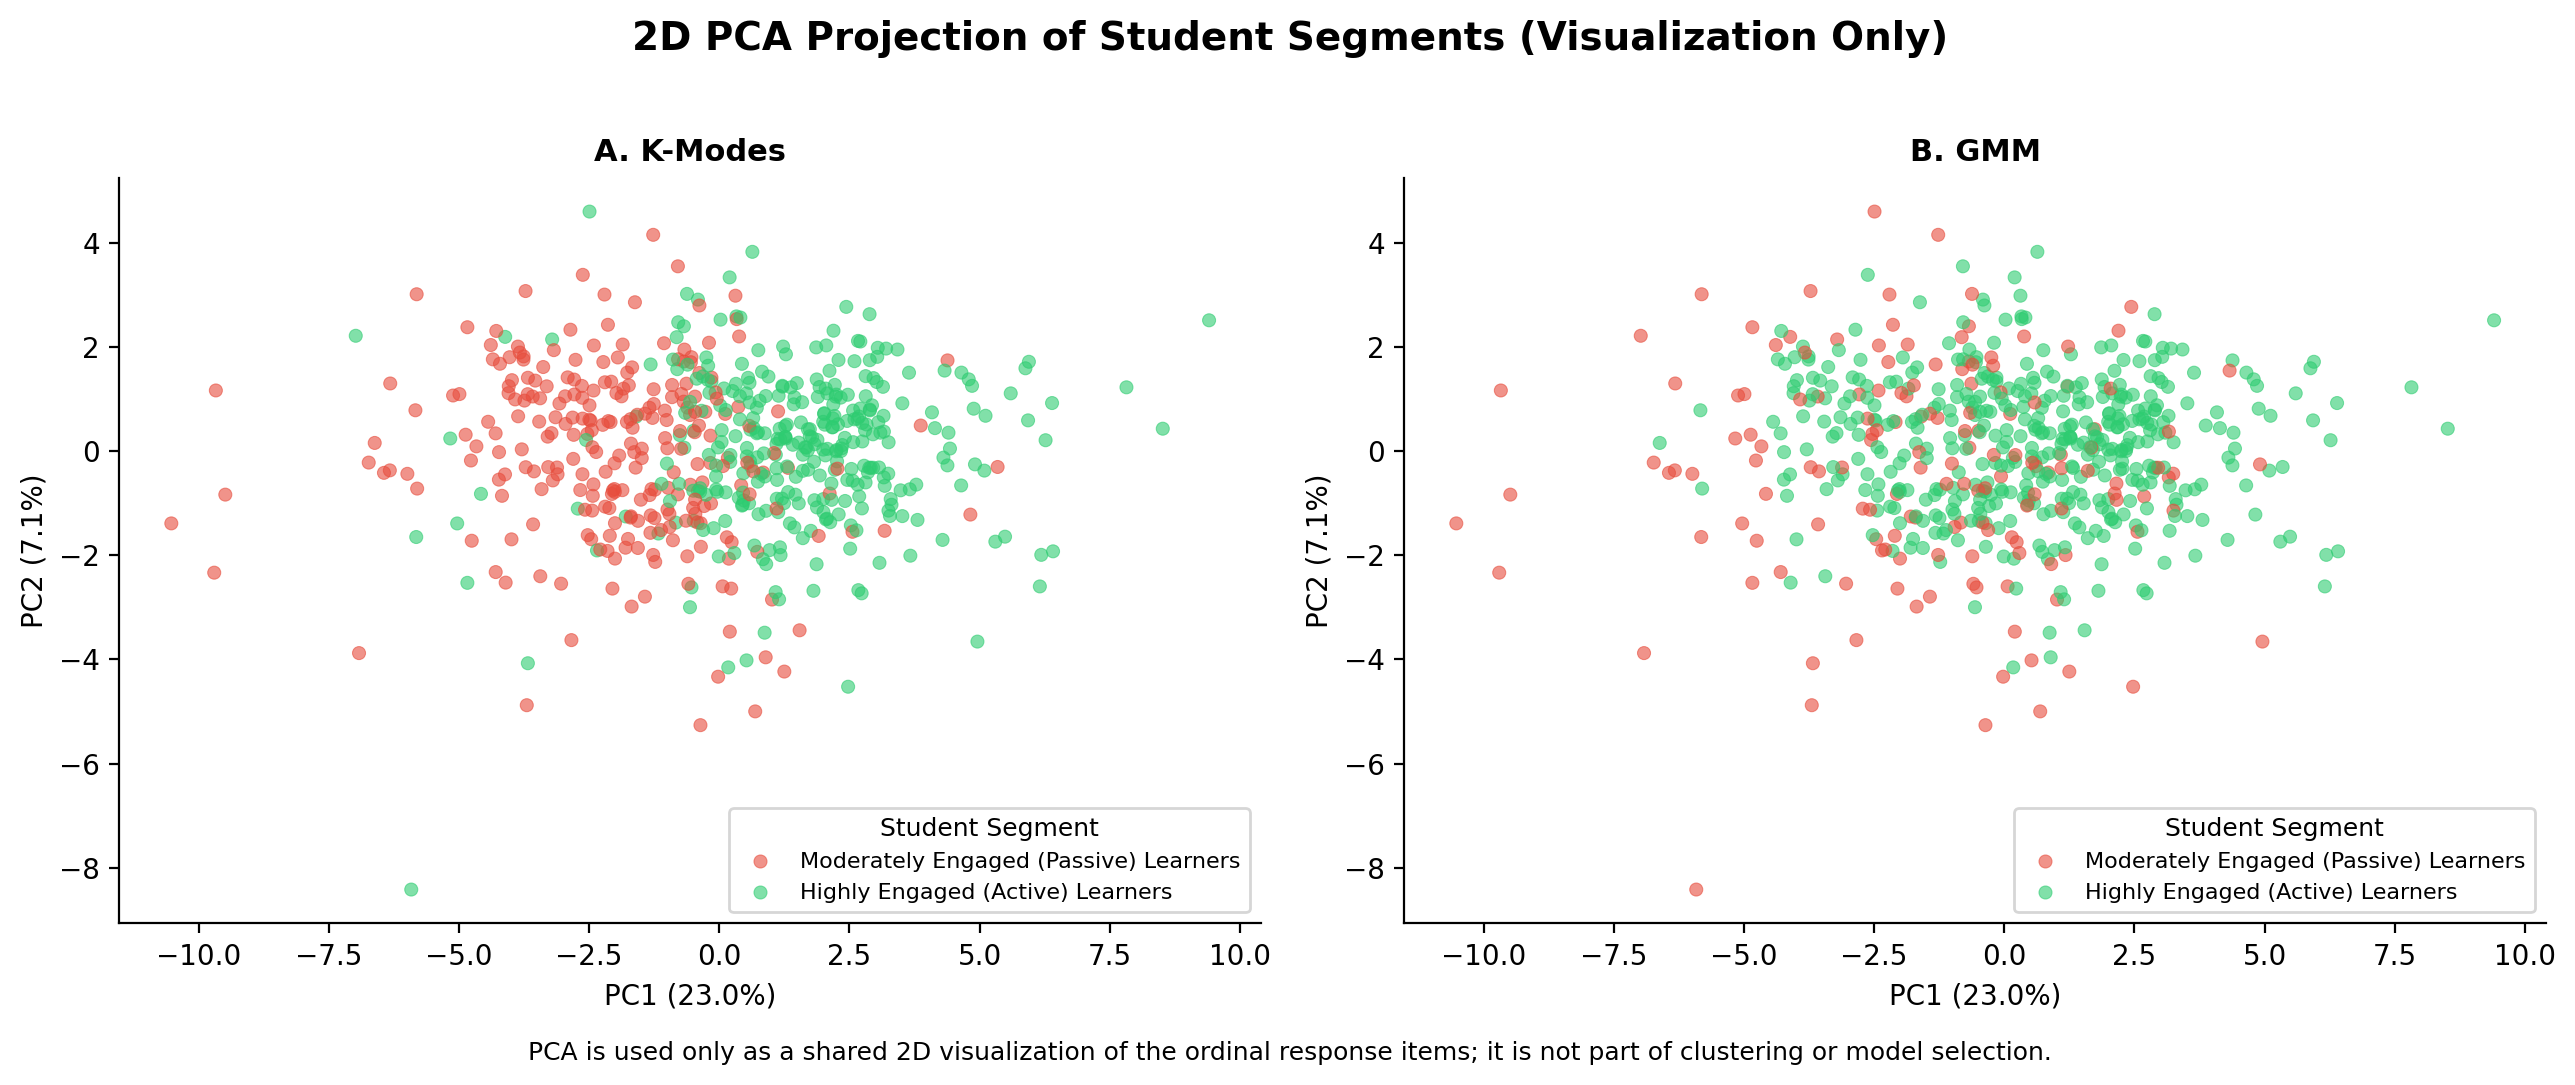

In [22]:
pca_cfg = seg_cfg["pca_visualisation"]
X_pca_vis = df[cluster_vars].copy().dropna()
idx_vis = X_pca_vis.index
X_pca_sc = StandardScaler().fit_transform(X_pca_vis)
cluster_order_labels = [label for label in label_cfg["preferred_order"] if label in df[label_cfg["label_column"]].dropna().unique()]
palette = pca_cfg["cluster_palette"]

pca_2 = PCA(n_components=pca_cfg["n_components_2d"], random_state=RANDOM_STATE)
X_pca_2d = pca_2.fit_transform(X_pca_sc)

km_labels_clean = df.loc[idx_vis, label_cfg["id_column"]].astype(int).map(cluster_name_map)
gmm_cluster_name_map, gmm_engagement_score, _ = build_auto_cluster_name_map(df.loc[idx_vis].copy(), "gmm_cluster_id", cluster_vars)
gmm_labels_clean = df.loc[idx_vis, "gmm_cluster_id"].astype(int).map(gmm_cluster_name_map)
vis_df = pd.DataFrame({"PC1": X_pca_2d[:, 0], "PC2": X_pca_2d[:, 1], "K-Modes": km_labels_clean, "GMM": gmm_labels_clean})

fig, axes = plt.subplots(1, 2, figsize=tuple(pca_cfg["figsize_2d_comparison"]), dpi=pca_cfg["dpi"])
fig.suptitle("2D PCA Projection of Student Segments (Visualization Only)", fontsize=14, fontweight="bold", y=1.02)
for ax, model_col, title in [(axes[0], "K-Modes", "A. K-Modes"), (axes[1], "GMM", "B. GMM")]:
    sns.scatterplot(data=vis_df, x="PC1", y="PC2", hue=model_col, hue_order=cluster_order_labels, palette=palette, s=pca_cfg["scatter_size"], alpha=pca_cfg["alpha"], edgecolor=None, ax=ax)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0] * 100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1] * 100:.1f}%)")
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(title="Student Segment", fontsize=8, title_fontsize=9, frameon=True)
fig.text(0.5, -0.02, "PCA is used only as a shared 2D visualization of the ordinal response items; it is not part of clustering or model selection.", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

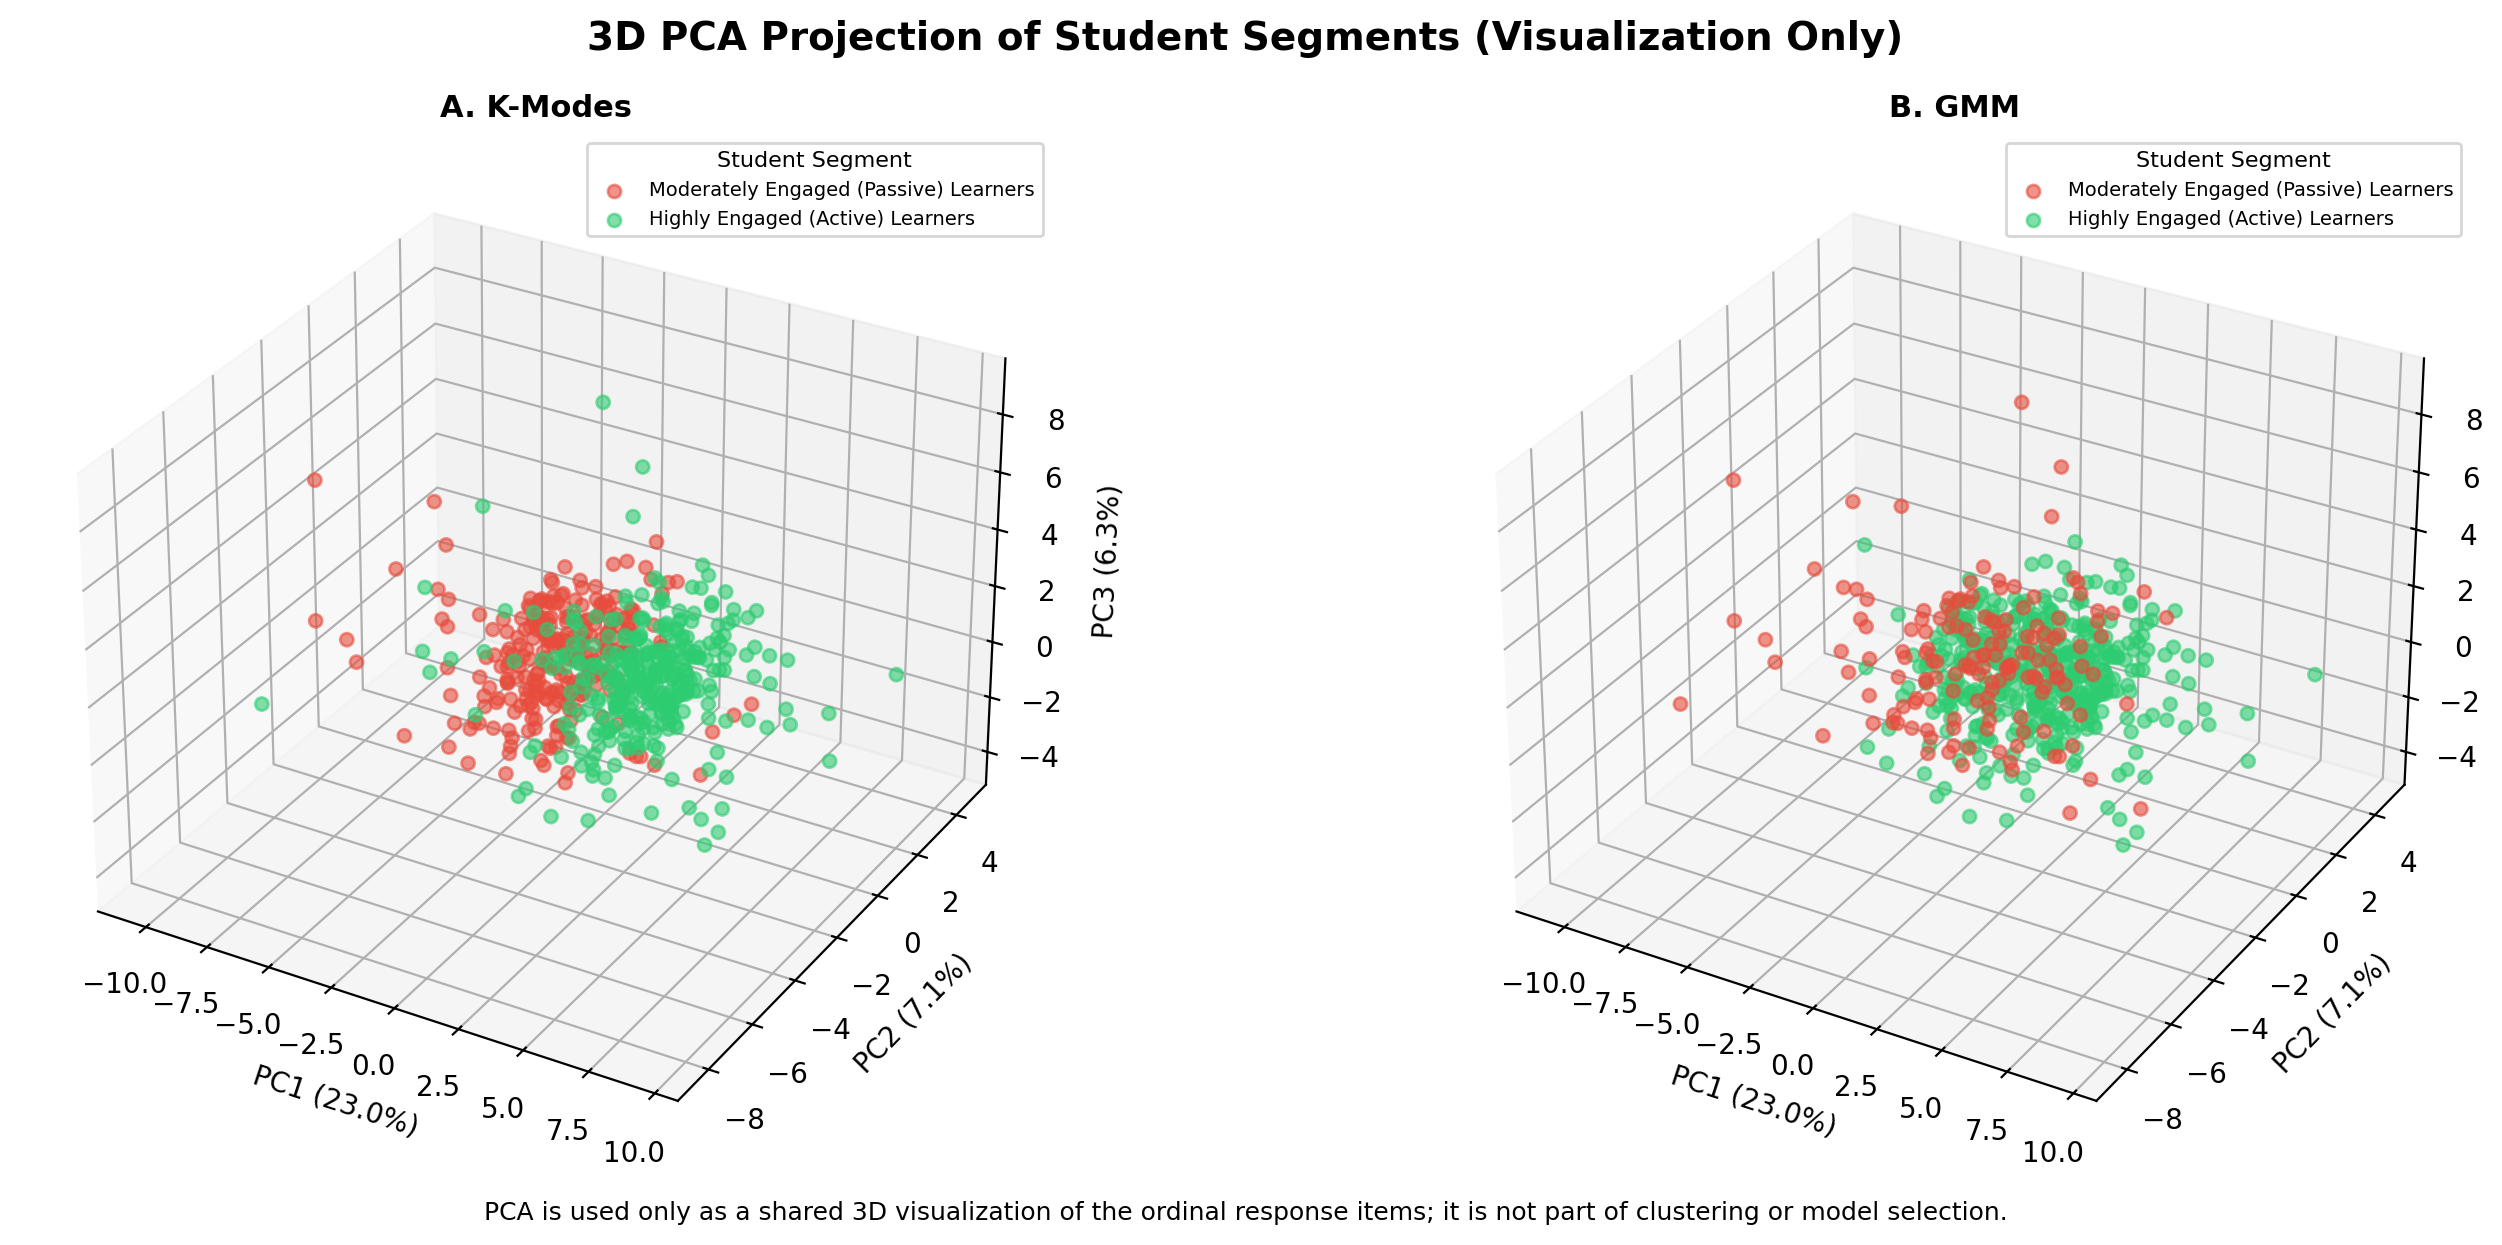

In [23]:
pca_3 = PCA(n_components=pca_cfg["n_components_3d"], random_state=RANDOM_STATE)
X_pca_3d = pca_3.fit_transform(X_pca_sc)
vis_3d_df = pd.DataFrame({"PC1": X_pca_3d[:, 0], "PC2": X_pca_3d[:, 1], "PC3": X_pca_3d[:, 2], "K-Modes": km_labels_clean, "GMM": gmm_labels_clean})
fig = plt.figure(figsize=tuple(pca_cfg["figsize_3d_comparison"]), dpi=pca_cfg["dpi"])
fig.suptitle("3D PCA Projection of Student Segments (Visualization Only)", fontsize=14, fontweight="bold", y=0.98)
for position, model_col, title in [(1, "K-Modes", "A. K-Modes"), (2, "GMM", "B. GMM")]:
    ax = fig.add_subplot(1, 2, position, projection="3d")
    for segment in cluster_order_labels:
        subset = vis_3d_df[vis_3d_df[model_col] == segment]
        ax.scatter(subset["PC1"], subset["PC2"], subset["PC3"], label=segment, color=palette.get(segment), s=pca_cfg["scatter_size"], alpha=pca_cfg["alpha"])
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(f"PC1 ({pca_3.explained_variance_ratio_[0] * 100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca_3.explained_variance_ratio_[1] * 100:.1f}%)")
    ax.set_zlabel(f"PC3 ({pca_3.explained_variance_ratio_[2] * 100:.1f}%)")
    ax.legend(title="Student Segment", fontsize=7, title_fontsize=8, frameon=True)
fig.text(0.5, -0.02, "PCA is used only as a shared 3D visualization of the ordinal response items; it is not part of clustering or model selection.", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 9. Post-hoc profiling tables, CA tables, and grouped bars

In [24]:
profile_vars = seg_cfg["profiling"]
age_col = profile_vars["age_col"]
if age_col in df.columns:
    display(df.groupby(label_cfg["id_column"])[age_col].describe())
    display(df.groupby(label_cfg["id_column"])[age_col].mean().round(2))

for var in profile_vars["categorical_vars"] + profile_vars["ordinal_vars"]:
    if var in df.columns:
        print(f"\n=== {var} by segment ===")
        display((pd.crosstab(df[label_cfg["id_column"]], df[var], normalize="index") * 100).round(1))

for group_name in profile_vars["multi_select_groups"]:
    cols = [col for col in multi_groups.get(group_name, []) if col in df.columns]
    if cols:
        print(f"\n=== {group_name} multi-select prevalence by segment ===")
        display((df.groupby(label_cfg["id_column"])[cols].mean() * 100).round(1))

,count,mean,std,min,25%,50%,75%,max
student_segment,,,,,,,,
1,263.0,20.216730,2.004429,17.0,19.0,20.0,21.0,36.0
2,329.0,20.392097,2.454724,17.0,19.0,20.0,21.0,43.0


student_segment
1    20.22
2    20.39
Name: age, dtype: float64


=== gender by segment ===


gender,Female,Male,Prefer Not To Say
student_segment,,,
1,32.3,66.5,1.1
2,32.5,65.7,1.8



=== education_level by segment ===


...

academic_year,2019–2020,2020–2021,2021–2022,2022–2023,2023–2024,2024–2025,2025–2026
student_segment,,,,,,,
1,0.4,1.9,2.7,5.3,6.8,23.6,59.3
2,0.3,0.6,2.4,4.6,3.3,23.1,65.7



=== challenges multi-select prevalence by segment ===


,ch_internet,ch_no_instructor_support,ch_motivation,ch_limited_interaction,ch_time_management,ch_isolation,ch_misunderstanding,ch_delayed_feedback,ch_asking_questions,ch_info_overload,ch_other
student_segment,,,,,,,,,,,
1,71.5,38.4,52.5,34.2,27.4,27.0,33.5,23.2,36.1,24.7,1.1
2,72.0,41.3,51.1,35.6,25.5,21.6,30.7,23.1,37.1,21.3,1.5



=== devices multi-select prevalence by segment ===


,device_mobile,device_tablet,device_laptop,device_desktop,device_other
student_segment,,,,,
1,85.6,27.0,85.2,10.6,0.4
2,82.1,36.2,85.1,10.6,0.6


In [25]:
df = add_satisfaction_bin(df)
ca_cfg = seg_cfg["correspondence_analysis"]

def run_ca(ctab: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, np.ndarray | None]:
    ca = prince.CA(n_components=ca_cfg["n_components"], n_iter=ca_cfg["n_iter"], copy=ca_cfg["copy"], engine=ca_cfg["engine"], random_state=RANDOM_STATE).fit(ctab)
    row_c = ca.row_coordinates(ctab)
    col_c = ca.column_coordinates(ctab)
    inertia = None
    try:
        eig = np.array(ca.eigenvalues_)
        if eig.sum() > 0:
            inertia = eig / eig.sum() * 100
    except Exception:
        pass
    return row_c, col_c, inertia

for row_var, col_var, title in ca_cfg["pairs"]:
    sub = df[[row_var, col_var]].dropna()
    ctab = pd.crosstab(sub[row_var], sub[col_var], normalize="index") * 100
    print(f"\n=== {title} ===")
    display(ctab.round(1))


=== Student Segment × Gender ===


gender,Female,Male,Prefer Not To Say
student_segment_label,,,
Moderately Engaged (Passive) Learners,32.3,66.5,1.1
Highly Engaged (Active) Learners,32.5,65.7,1.8



=== Student Segment × Education Level ===


education_level,Master,Other,PHD,Year1 - Freshman,Year2 - Sophomore,Year3 - Junior,Year4 - Senior,Year5 - Final Year
student_segment_label,,,,,,,,
Moderately Engaged (Passive) Learners,2.3,2.3,0.0,4.9,54.0,15.2,13.3,8.0
Highly Engaged (Active) Learners,4.6,1.5,0.3,3.0,50.8,14.9,14.9,10.0



=== Student Segment × Ideal Blend ===


ideal_balance,"Balanced Half and Half (50% In-person, 50% Online)","More Face-to-Face than Online (e.g., 60% In-person, 40% Online)","More Online than Face-to-Face (e.g., 40% In-person, 60% Online)","Mostly Face-to-Face (e.g., 80% In-person, 20% Online)","Mostly Online (e.g., 20% In-person, 80% Online)"
student_segment_label,,,,,
Moderately Engaged (Passive) Learners,20.2,25.9,6.5,44.5,3.0
Highly Engaged (Active) Learners,21.6,31.0,6.1,38.3,3.0



=== Student Segment × Prefer More Blended ===


prefer_more_blended,Neutral/Unsure,No,Yes
student_segment_label,,,
Moderately Engaged (Passive) Learners,57.4,6.8,35.7
Highly Engaged (Active) Learners,28.3,3.0,68.7



=== Student Segment × Satisfaction ===


sat_bin,Low (1-2),Medium (3),High (4-5)
student_segment_label,,,
Moderately Engaged (Passive) Learners,10.3,64.6,25.1
Highly Engaged (Active) Learners,5.2,22.5,72.3


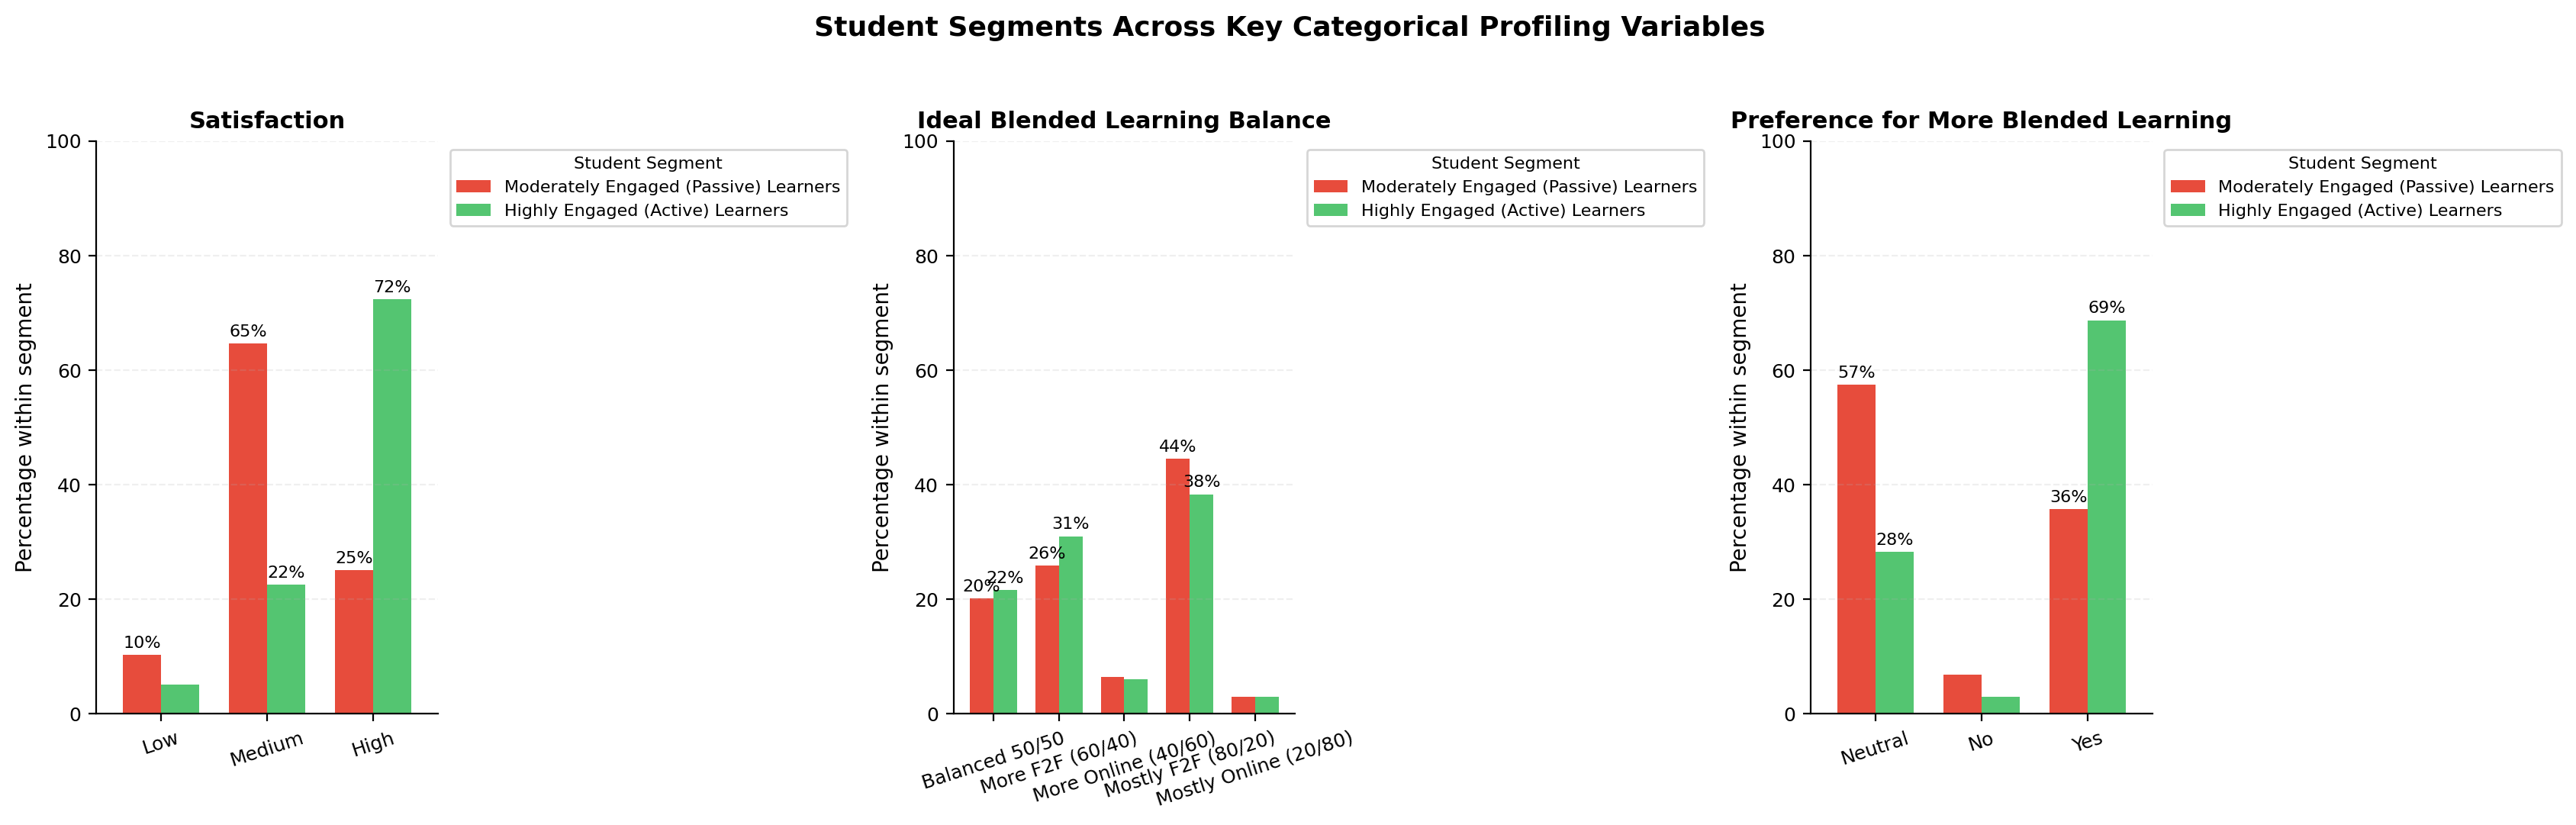

In [26]:
bar_cfg = seg_cfg["bar_charts"]
segment_order = [label for label in label_cfg["preferred_order"] if label in df[label_cfg["label_column"]].dropna().unique()]
fig, axes = plt.subplots(1, len(bar_cfg["variables"]), figsize=tuple(bar_cfg["figsize"]), dpi=bar_cfg["dpi"])
if len(bar_cfg["variables"]) == 1:
    axes = [axes]
fig.suptitle("Student Segments Across Key Categorical Profiling Variables", fontsize=13, fontweight="bold", y=1.03)

for ax, (var, title) in zip(axes, bar_cfg["variables"]):
    sub = df[[label_cfg["label_column"], var]].dropna().copy()
    display_map = bar_cfg["display_maps"].get(var, {})
    if display_map:
        sub[var] = sub[var].map(lambda x: display_map.get(str(x), str(x)))
    tab = pd.crosstab(sub[var], sub[label_cfg["label_column"]], normalize="columns") * 100
    existing_segments = [segment for segment in segment_order if segment in tab.columns]
    tab = tab[existing_segments]
    colors = [bar_cfg["segment_color_map"].get(segment, bar_cfg["default_color"]) for segment in existing_segments]
    tab.plot(kind="bar", ax=ax, width=0.72, color=colors)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Percentage within segment")
    ax.set_ylim(0, 100)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", alpha=0.20, linestyle="--")
    ax.tick_params(axis="x", rotation=18, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.legend(title="Student Segment", fontsize=8, title_fontsize=8, frameon=True, loc="upper left", bbox_to_anchor=(1.01, 1.0))
    for container in ax.containers:
        labels = [f"{bar.get_height():.0f}%" if bar.get_height() >= bar_cfg["min_bar_label_percent"] else "" for bar in container]
        ax.bar_label(container, labels=labels, padding=2, fontsize=8)
plt.tight_layout()
plt.show()

## 10. Save dataset with final segment labels

In [27]:
output_path = resolve_path_from_settings(settings, io_cfg["output_cluster_path_key"], from_path_dict=True)
output_path.parent.mkdir(parents=True, exist_ok=True)

# Convert categorical segment label to string before saving to CSV.
df_to_save = df.copy()
df_to_save[label_cfg["label_column"]] = df_to_save[label_cfg["label_column"]].astype(str)
df_to_save.to_csv(output_path, **io_cfg["write_csv_options"])

print(f"Dataset with clustering results saved to: {output_path}")
print(f"Final shape: {df_to_save.shape}")
print("\nCluster counts:")
print(df_to_save[label_cfg["label_column"]].value_counts())

Dataset with clustering results saved to: /Users/ougi/Documents/Project/Blended-Learning/ml/data/processed/cluster_data.csv
Final shape: (592, 94)

Cluster counts:
student_segment_label
Highly Engaged (Active) Learners         329
Moderately Engaged (Passive) Learners    263
Name: count, dtype: int64
